# W-State Preparation and Entanglement Verification on IQM Hardware

Uses IQM's built-in `get_circuit(CircuitType.WSTATE, n)` for circuit preparation,
optimal qubit selection via `CostEvaluator`, and Z/X-basis measurements to verify genuine multipartite entanglement.

In [16]:
# ── Configuration ─────────────────────────────────────────────────────────────
N_QUBITS = 30
SHOTS    = 200

## 1. Connect to IQM Resonance

In [17]:
import os
from pathlib import Path
from iqm.qiskit_iqm import IQMProvider

secret_path = Path().cwd() / ".secrets" / "iqm_api_key"
if secret_path.exists():
    api_token = secret_path.read_text().strip()
    print("Using API token from .secrets/iqm_api_key")
else:
    api_token = input("Enter your IQM Resonance API token: ").strip()

os.environ["IQM_TOKEN"] = api_token

provider = IQMProvider("https://resonance.meetiqm.com", quantum_computer="emerald")
backend  = provider.get_backend()
print(f"Connected to: {backend.name}  ({backend.num_qubits} qubits)")

Using API token from .secrets/iqm_api_key
Connected to: IQMBackend  (54 qubits)


## 2. Build the W-state circuit

`get_circuit(CircuitType.WSTATE, n)` from IQM's `qubit_selector` uses the same F-gate (Diker) algorithm — `Ry(-θ) · CZ · Ry(+θ)` chain followed by CNOT corrections, O(N) gates total.

W30: depth=61, ops={'ry': 58, 'measure': 30, 'cz': 29, 'cx': 29, 'x': 1, 'barrier': 1}


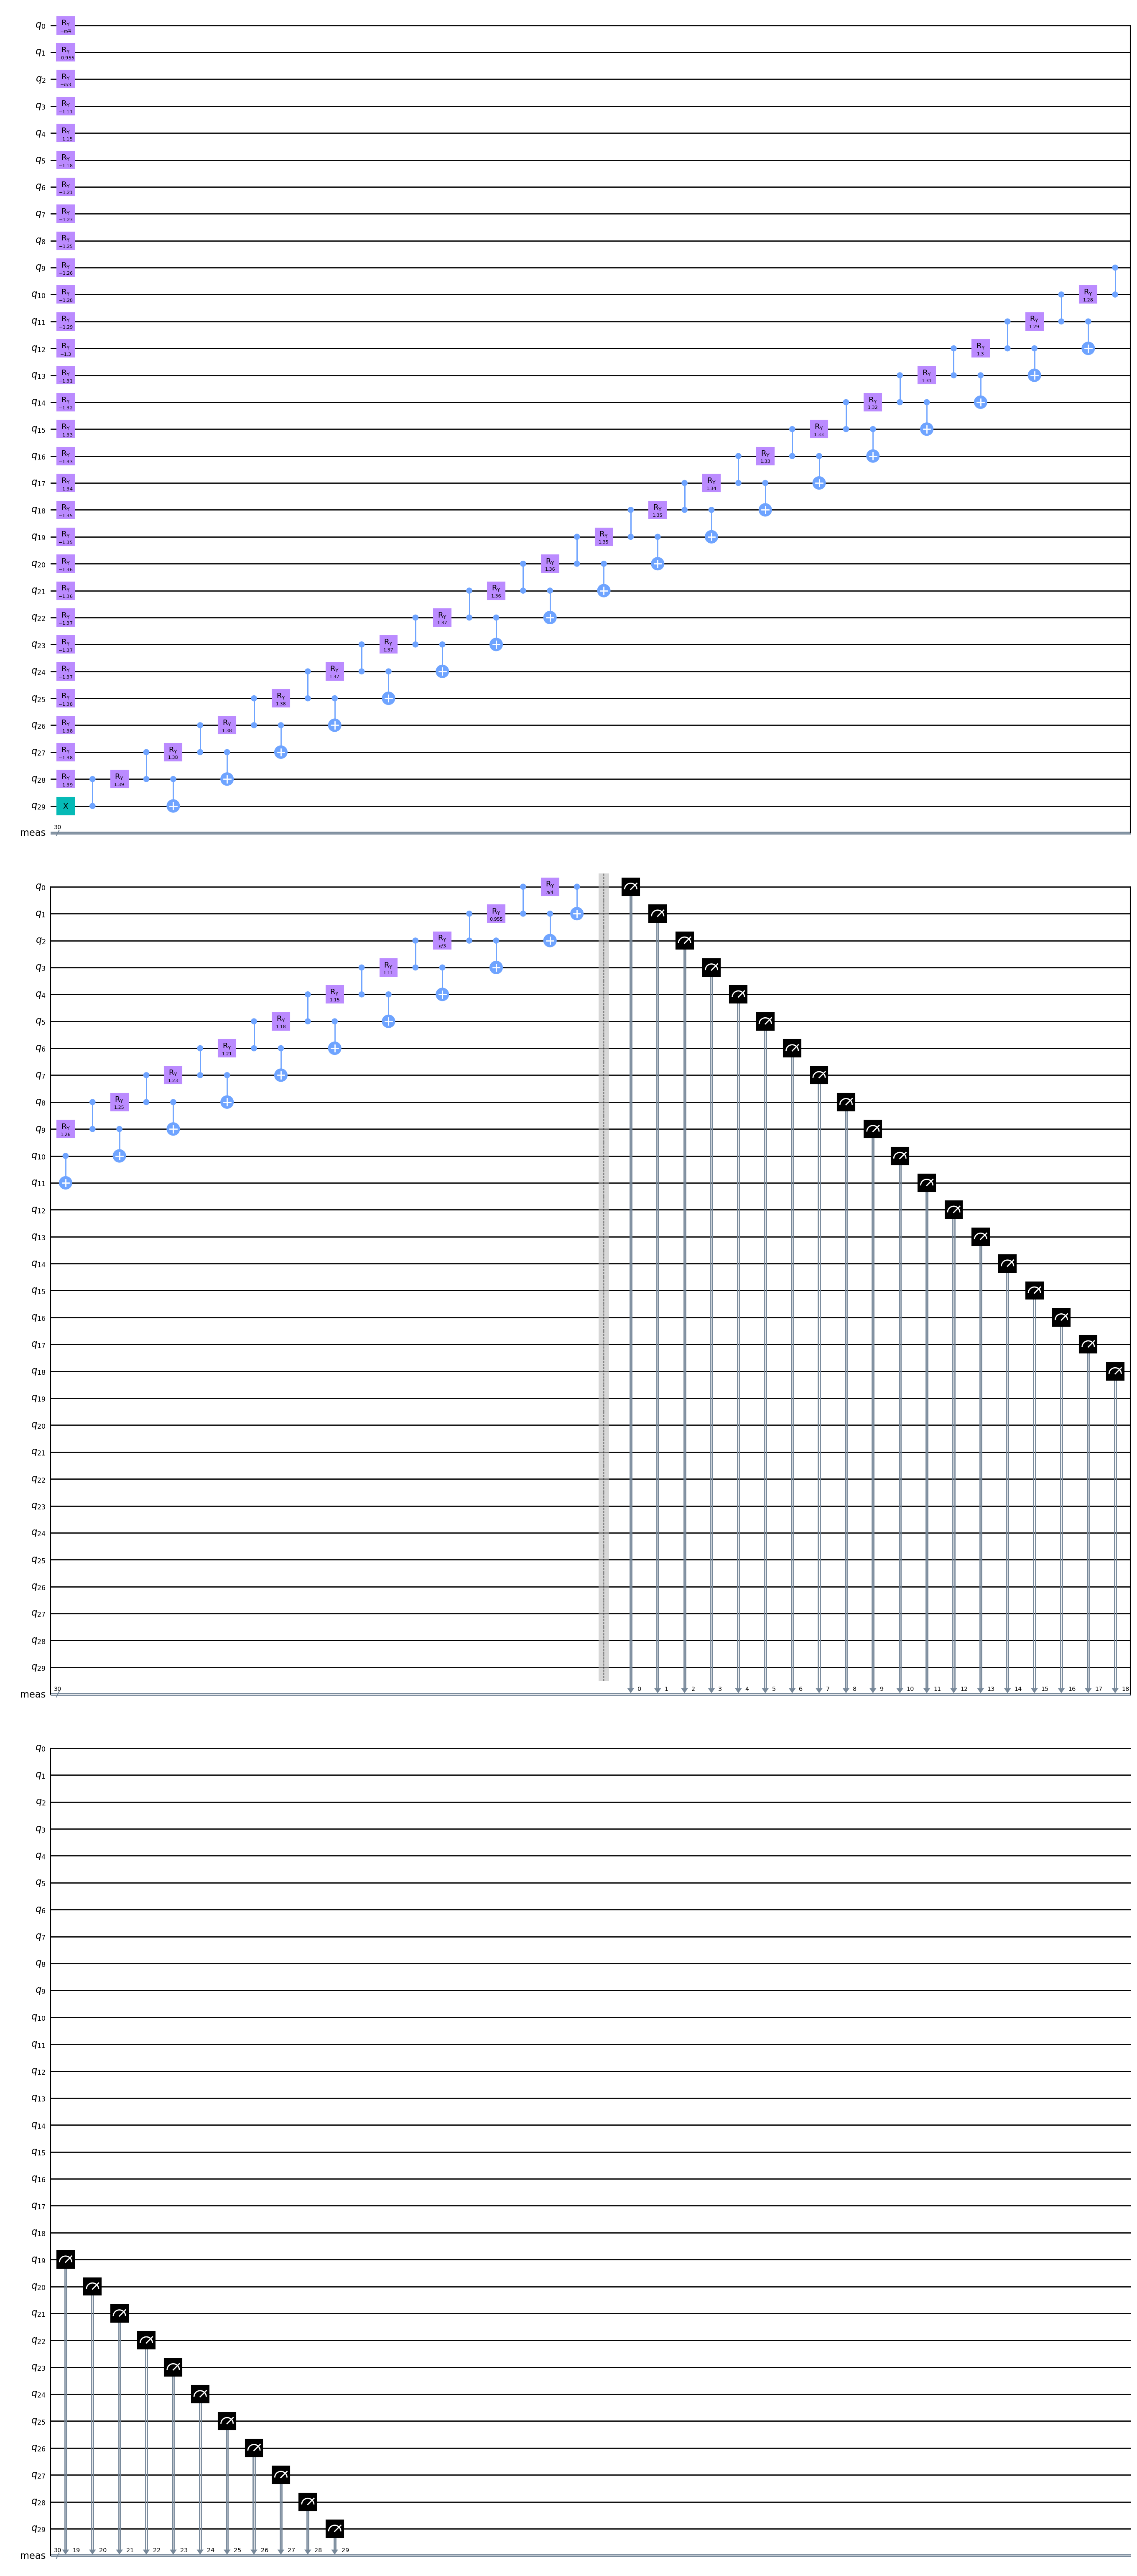

In [18]:
from iqm.qubit_selector.qiskit_utils import get_circuit, CircuitType

qc_w = get_circuit(CircuitType.WSTATE, N_QUBITS)
print(f"W{N_QUBITS}: depth={qc_w.depth()}, ops={dict(qc_w.count_ops())}")
qc_w.draw("mpl", style="clifford", fold=40)

## 3. Select optimal qubits

`CostEvaluator` ranks all valid N-qubit connected subgraphs by CZ gate error + QND readout fidelity.
**QNDNESS** (Quantum Non-Demolition) weights the cost by how well each qubit's readout preserves the post-measurement state — important here since we measure at the end of the W-state prep.

In [19]:
from iqm.qubit_selector.qubit_selector import (
    CalibrationDataManager,
    CostEvaluator,
    ReadoutMode,
    CostFunction,
)

qc_for_selector = get_circuit(CircuitType.WSTATE, N_QUBITS)
qc_for_selector.measure_all()

calibration_data = CalibrationDataManager().get_calibration_fidelities(backend)

layouts, costs = CostEvaluator(
    backend=backend,
    quantum_circuit=qc_for_selector,
    cost_function=CostFunction.GATE_COST_CZ,
    readoutmode=ReadoutMode.QNDNESS,
    num_trials=2000,
).get_top_layouts(num_layouts=20)

print(f"Top 5 layouts (lowest cost = best fidelity):")
for rank, (layout, cost) in enumerate(zip(layouts[:5], costs[:5]), 1):
    names = [backend.index_to_qubit_name(q) for q in layout]
    print(f"  Rank {rank}: {names}  cost={cost:.4f}")

best_layout = list(layouts[0])
best_names  = [backend.index_to_qubit_name(q) for q in best_layout]
print(f"\nSelected qubits: {best_names}")

[05-09 14:40:45;I] Number of layouts to evaluate: 355
[05-09 14:41:03;I] Cost evaluation has begun using cost function "gate_cost_cz".
Top 5 layouts (lowest cost = best fidelity):
  Rank 1: ['QB3', 'QB4', 'QB5', 'QB6', 'QB9', 'QB10', 'QB11', 'QB12', 'QB13', 'QB16', 'QB17', 'QB18', 'QB19', 'QB20', 'QB21', 'QB24', 'QB25', 'QB26', 'QB29', 'QB30', 'QB34', 'QB35', 'QB36', 'QB37', 'QB38', 'QB39', 'QB44', 'QB45', 'QB50', 'QB51']  cost=0.8455
  Rank 2: ['QB3', 'QB4', 'QB5', 'QB6', 'QB9', 'QB10', 'QB11', 'QB12', 'QB13', 'QB16', 'QB17', 'QB18', 'QB19', 'QB20', 'QB21', 'QB24', 'QB25', 'QB26', 'QB27', 'QB29', 'QB30', 'QB35', 'QB36', 'QB37', 'QB38', 'QB39', 'QB44', 'QB45', 'QB50', 'QB51']  cost=0.8492
  Rank 3: ['QB3', 'QB4', 'QB5', 'QB6', 'QB9', 'QB10', 'QB11', 'QB12', 'QB13', 'QB16', 'QB17', 'QB18', 'QB19', 'QB20', 'QB21', 'QB24', 'QB25', 'QB26', 'QB29', 'QB30', 'QB31', 'QB34', 'QB35', 'QB36', 'QB37', 'QB39', 'QB44', 'QB45', 'QB50', 'QB51']  cost=0.8493
  Rank 4: ['QB3', 'QB4', 'QB5', 'QB6', 'QB9

### Selected qubit path on device topology

The W-state has a linear interaction chain. VF2 finds hardware paths matching it; numbers show logical qubit order (the F-gate excitation flows from the highest-numbered qubit down to 0).

Qubits with edges: 52   total edges: 81
Degree distribution: [1, 2, 3, 4]
Corner qubit: 53  degree=1  neighbours=[52]
Placed 48/52 qubits on grid


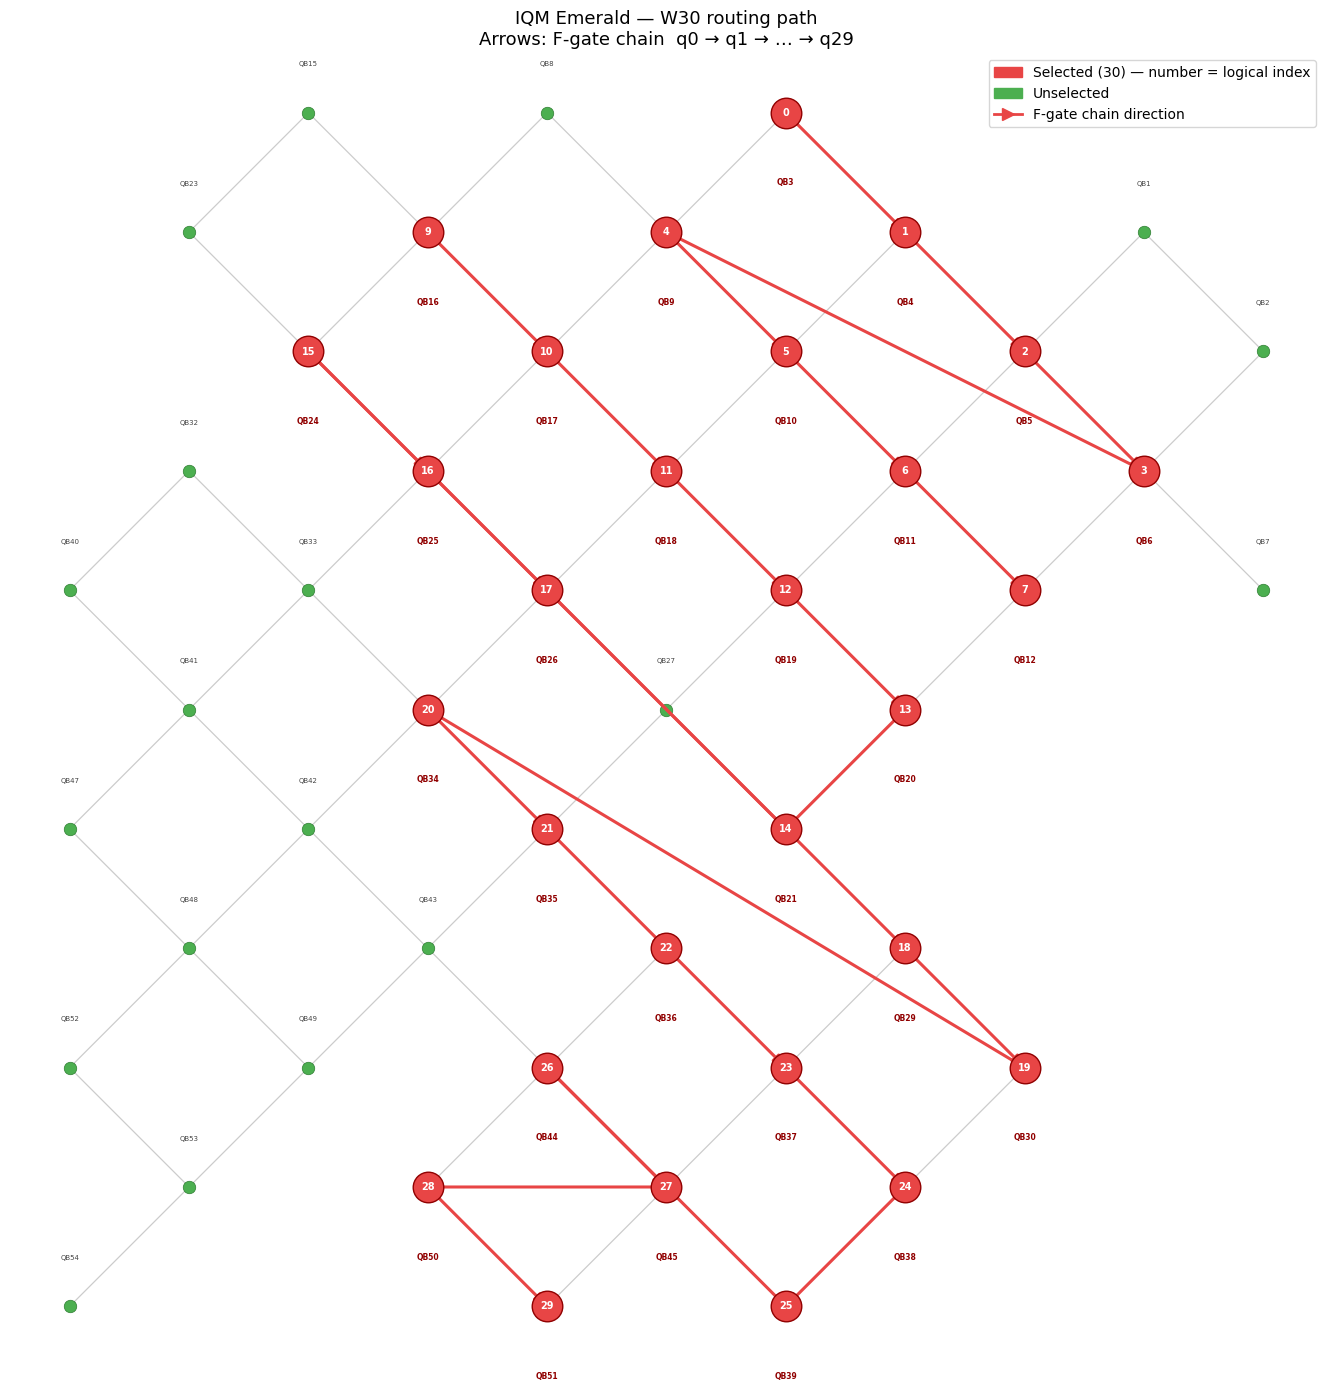

In [23]:
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
from collections import deque

def get_grid_positions(coupling_map):
    # Use get_edges() to stay in physical-qubit space — avoids graph node index confusion
    edges_list = list(coupling_map.get_edges())

    adj = {}
    for u, v in edges_list:
        adj.setdefault(u, set()).add(v)
        adj.setdefault(v, set()).add(u)

    print(f"Qubits with edges: {len(adj)}   total edges: {len(edges_list)}")
    print(f"Degree distribution: {sorted(set(len(v) for v in adj.values()))}")

    # Degree-2 corner as BFS start
    corner = min(adj, key=lambda q: len(adj[q]))
    nbrs   = sorted(adj[corner])
    print(f"Corner qubit: {corner}  degree={len(nbrs)}  neighbours={nbrs}")

    coords = {corner: (0, 0)}
    used   = {(0, 0)}
    coords[nbrs[0]] = (1, 0);  used.add((1, 0))
    if len(nbrs) > 1:
        coords[nbrs[1]] = (0, 1); used.add((0, 1))

    queue   = deque(coords.keys())
    offsets = [(1,0),(-1,0),(0,1),(0,-1)]

    while queue:
        node = queue.popleft()
        x, y = coords[node]
        for nbr in adj[node]:
            if nbr in coords:
                continue
            placed = [n2 for n2 in adj[nbr] if n2 in coords]
            for dx, dy in offsets:
                p = (x+dx, y+dy)
                if p in used:
                    continue
                if all(abs(p[0]-coords[n2][0]) + abs(p[1]-coords[n2][1]) == 1
                       for n2 in placed):
                    coords[nbr] = p; used.add(p)
                    queue.append(nbr)
                    break

    print(f"Placed {len(coords)}/{len(adj)} qubits on grid")
    return coords   # physical qubit index → (grid_x, grid_y)


grid = get_grid_positions(backend.coupling_map)

def to_display(gx, gy):
    return float(gx - gy), float(gx + gy)

disp = {phys: to_display(*gxy) for phys, gxy in grid.items()}

# ── Edge list for drawing (physical qubit pairs) ───────────────────────────
all_edges = [(u, v) for u, v in backend.coupling_map.get_edges()]

selected_set    = set(best_layout)
chain_pairs     = [(best_layout[i], best_layout[i+1]) for i in range(N_QUBITS-1)]
chain_set       = {frozenset(p) for p in chain_pairs}
phys_to_logical = {phys: log for log, phys in enumerate(best_layout)}

fig, ax = plt.subplots(figsize=(14, 14))
ax.set_aspect("equal")

# Non-chain edges
drawn = set()
for pa, pb in all_edges:
    key = frozenset((pa, pb))
    if key in chain_set or key in drawn:
        continue
    drawn.add(key)
    if pa in disp and pb in disp:
        x0,y0 = disp[pa]; x1,y1 = disp[pb]
        ax.plot([x0,x1],[y0,y1], color="#cccccc", lw=0.9, zorder=1)

# Chain edges as arrows
for pa, pb in chain_pairs:
    if pa in disp and pb in disp:
        x0,y0 = disp[pa]; x1,y1 = disp[pb]
        ax.annotate("", xy=(x1,y1), xytext=(x0,y0),
                    arrowprops=dict(arrowstyle="-|>", color="#e84545",
                                   lw=2.2, mutation_scale=14), zorder=4)

# Unselected nodes
for phys, (px, py) in disp.items():
    if phys not in selected_set:
        ax.plot(px, py, "o", markersize=9, color="#4CAF50",
                markeredgecolor="#2e7d32", markeredgewidth=0.5, zorder=2)
        ax.text(px, py+0.38, backend.index_to_qubit_name(phys),
                ha="center", va="bottom", fontsize=5, color="#444444", zorder=3)

# Selected nodes
for phys in selected_set:
    if phys not in disp:
        continue
    px, py = disp[phys]
    log    = phys_to_logical[phys]
    ax.plot(px, py, "o", markersize=22, color="#e84545",
            markeredgecolor="#900000", markeredgewidth=1.0, zorder=5)
    ax.text(px, py, str(log), ha="center", va="center",
            fontsize=7, fontweight="bold", color="white", zorder=6)
    ax.text(px, py-0.55, backend.index_to_qubit_name(phys),
            ha="center", va="top", fontsize=5.5,
            color="#900000", fontweight="bold", zorder=6)

ax.legend(handles=[
    mpatches.Patch(color="#e84545", label=f"Selected ({N_QUBITS}) — number = logical index"),
    mpatches.Patch(color="#4CAF50", label="Unselected"),
    plt.Line2D([0],[0], color="#e84545", lw=2, marker=">", ms=8, label="F-gate chain direction"),
], loc="upper right", fontsize=10)
ax.set_title(
    f"IQM Emerald — W{N_QUBITS} routing path\n"
    f"Arrows: F-gate chain  q0 → q1 → … → q{N_QUBITS-1}",
    fontsize=13)
ax.axis("off")
plt.tight_layout()
plt.show()

## 4. Z-basis and X-basis circuits

- **Z-basis**: measure immediately after W-state prep → occupation probabilities  
- **X-basis**: apply H to every qubit before measurement → probes ⟨Xi Xj⟩ correlators

In [ ]:
from qiskit import transpile

qc_z = get_circuit(CircuitType.WSTATE, N_QUBITS)
qc_z.measure_all()

qc_x = get_circuit(CircuitType.WSTATE, N_QUBITS)
qc_x.h(range(N_QUBITS))
qc_x.measure_all()

def transpile_on_best(qc):
    return transpile(qc, backend=backend, initial_layout=best_layout, optimization_level=3)

qc_z_t = transpile_on_best(qc_z)
qc_x_t = transpile_on_best(qc_x)
print(f"Z-basis depth after transpilation: {qc_z_t.depth()}")
print(f"X-basis depth after transpilation: {qc_x_t.depth()}")

Z-basis depth after transpilation: 223
X-basis depth after transpilation: 237


## 5. Run on hardware

In [ ]:
print(f"Submitting {SHOTS} shots × 2 circuits  (N={N_QUBITS})...")
job_z = backend.run(qc_z_t, shots=SHOTS)
job_x = backend.run(qc_x_t, shots=SHOTS)
print(f"Z-basis job: {job_z.job_id()}")
print(f"X-basis job: {job_x.job_id()}")

Submitting 200 shots × 2 circuits  (N=30)...
Z-basis job: 019e0c98-2354-75c3-9f9e-c7fc97f51c91
X-basis job: 019e0c98-2884-7e33-9c8d-04aaaece1db9


In [ ]:
counts_z = job_z.result().get_counts()
counts_x = job_x.result().get_counts()
print("Z-basis counts:", counts_z)
print("X-basis counts:", counts_x)

[05-09 13:55:59;I] Waiting for job 019e0c98-2354-75c3-9f9e-c7fc97f51c91 to finish...
[05-09 13:56:02;I] Waiting for job 019e0c98-2884-7e33-9c8d-04aaaece1db9 to finish...
Z-basis counts: {'000001100000100100001101000010 000001100000100100001101000010': 1, '000001011000100101001000111100 000001011000000101000000111100': 1, '000000011000111001101110001100 000000011001111001101110001100': 1, '000010010010000101110010010000 000010010010010001110010010000': 1, '000111000000000111011111000000 000111000000000111011111000001': 1, '000000100101000101011000111000 000000100101001101011000111000': 1, '000010000000010010010100000000 000010000000010010010100000000': 1, '111000100100000011110101011001 111000101110000111110101011001': 1, '000011100000011000110111001000 000011101000011000110111001000': 1, '001001000000011100000000000000 001001000000011100000000000000': 1, '000001000000011001001101111000 000001000000011001001101111000': 1, '000001100100001100000111000000 000001100100001100000111100000': 

## 6. Z-basis analysis

For ideal |W_N⟩ only the N single-excitation bitstrings appear, each with probability 1/N.

W30 Z-basis fidelity (fraction in valid outcomes): 0.000  (ideal: 1.000)
Total shots: 200

Non-zero outcomes:
  ✗ |000001100000100100001101000010 000001100000100100001101000010⟩  count=1  prob=0.005
  ✗ |000001011000100101001000111100 000001011000000101000000111100⟩  count=1  prob=0.005
  ✗ |000000011000111001101110001100 000000011001111001101110001100⟩  count=1  prob=0.005
  ✗ |000010010010000101110010010000 000010010010010001110010010000⟩  count=1  prob=0.005
  ✗ |000111000000000111011111000000 000111000000000111011111000001⟩  count=1  prob=0.005
  ✗ |000000100101000101011000111000 000000100101001101011000111000⟩  count=1  prob=0.005
  ✗ |000010000000010010010100000000 000010000000010010010100000000⟩  count=1  prob=0.005
  ✗ |111000100100000011110101011001 111000101110000111110101011001⟩  count=1  prob=0.005
  ✗ |000011100000011000110111001000 000011101000011000110111001000⟩  count=1  prob=0.005
  ✗ |001001000000011100000000000000 001001000000011100000000000000⟩  count=1  prob=0.005


C:\Users\MI\AppData\Local\Temp\ipykernel_48004\879630125.py:31: UserWarning: Tight layout not applied. The bottom and top margins cannot be made large enough to accommodate all Axes decorations.
  plt.tight_layout()


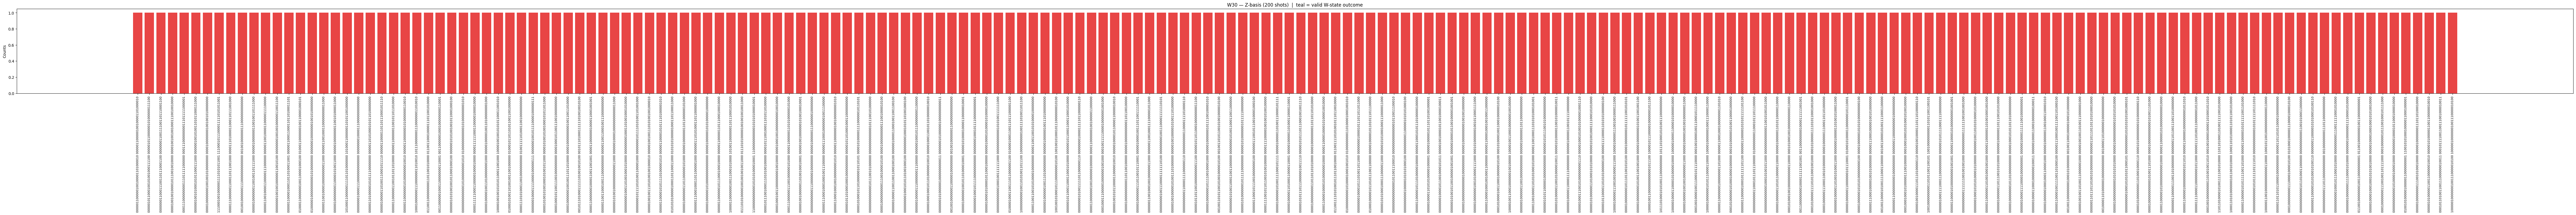

In [22]:
import numpy as np
import matplotlib.pyplot as plt

total_z     = sum(counts_z.values())
probs_z     = {k: v / total_z for k, v in counts_z.items()}
w_bitstrings = {format(1 << i, f"0{N_QUBITS}b") for i in range(N_QUBITS)}
fidelity_z  = sum(probs_z.get(s, 0) for s in w_bitstrings)

print(f"W{N_QUBITS} Z-basis fidelity (fraction in valid outcomes): {fidelity_z:.3f}  (ideal: 1.000)")
print(f"Total shots: {total_z}")
print(f"\nNon-zero outcomes:")
for bs, p in sorted(probs_z.items(), key=lambda x: -x[1]):
    tag = "✓" if bs in w_bitstrings else "✗"
    print(f"  {tag} |{bs}⟩  count={counts_z[bs]}  prob={p:.3f}")

print(f"\nMarginal P(q_i=1)  (ideal: {1/N_QUBITS:.3f}):")
for qi in range(N_QUBITS):
    p1 = sum(v for k, v in probs_z.items() if k[-(qi + 1)] == "1")
    print(f"  q{qi}: {p1:.3f}")

# Bar chart
sorted_counts = sorted(counts_z.items(), key=lambda x: -x[1])
labels, vals  = zip(*sorted_counts)
colors = ["#32a8a4" if lb in w_bitstrings else "#e84545" for lb in labels]
fig, ax = plt.subplots(figsize=(max(8, len(labels) * 0.6), 4))
ax.bar(range(len(labels)), vals, color=colors)
ax.set_xticks(range(len(labels)))
ax.set_xticklabels(labels, rotation=90, fontsize=8)
ax.set_ylabel("Counts")
ax.set_title(f"W{N_QUBITS} — Z-basis ({SHOTS} shots)  |  teal = valid W-state outcome")
plt.tight_layout()
plt.show()

## 7. X-basis correlators and entanglement witness

Quantum |W_N⟩ predicts ⟨Xi Xj⟩ = 2/N for all i≠j.  
A classical "one random qubit excited" mixture predicts ⟨Xi Xj⟩ = 0.  
The average over all pairs is the entanglement witness W — positive W witnesses genuine entanglement.

Entanglement witness W for W30:
  Classical (separable): 0.0000
  Ideal W state:         0.0667
  Hardware measurement:  0.1764
  Shot noise ±:          0.0707


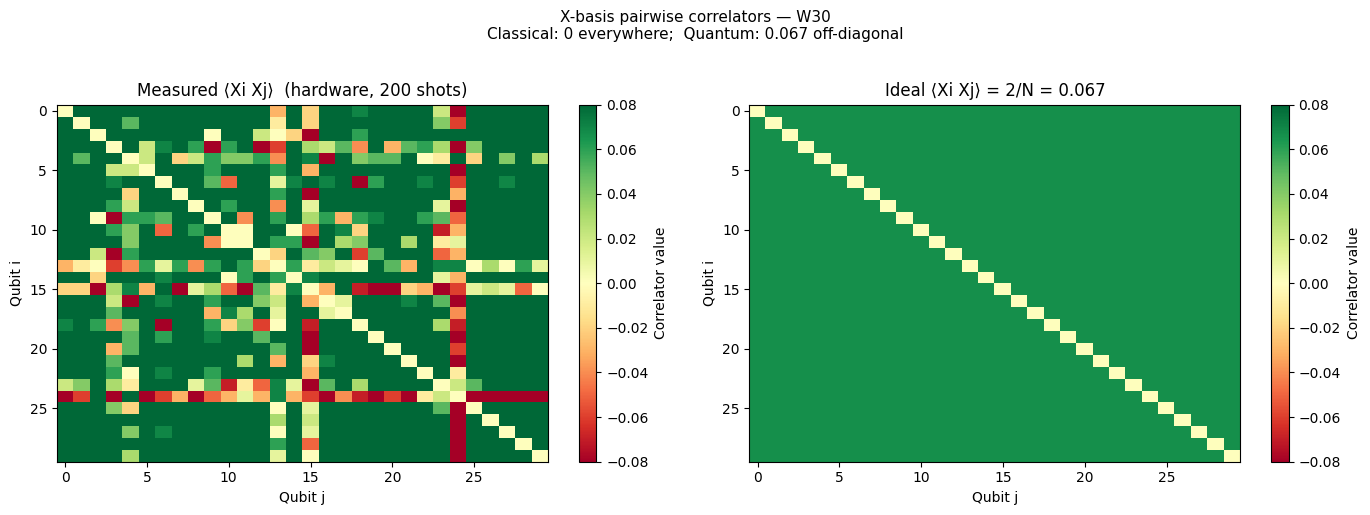

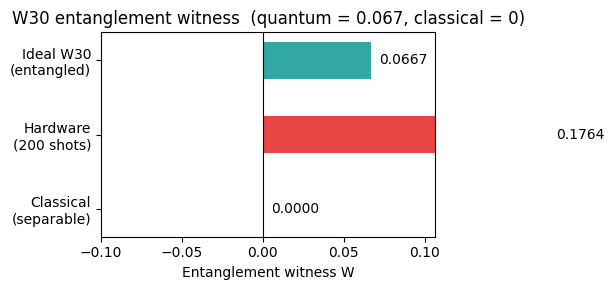

In [ ]:
total_x = sum(counts_x.values())
probs_x = {k: v / total_x for k, v in counts_x.items()}

def expectation_xi_xj(probs, i, j):
    val = 0.0
    for bitstr, prob in probs.items():
        ei = 1 - 2 * int(bitstr[-(i + 1)])
        ej = 1 - 2 * int(bitstr[-(j + 1)])
        val += ei * ej * prob
    return val

corr_matrix = np.zeros((N_QUBITS, N_QUBITS))
for i in range(N_QUBITS):
    for j in range(i + 1, N_QUBITS):
        c = expectation_xi_xj(probs_x, i, j)
        corr_matrix[i, j] = c
        corr_matrix[j, i] = c

ideal_corr  = 2 / N_QUBITS
avg_corr    = corr_matrix[np.triu_indices(N_QUBITS, k=1)].mean()
shot_stderr = 1 / np.sqrt(SHOTS)

print(f"Entanglement witness W for W{N_QUBITS}:")
print(f"  Classical (separable): 0.0000")
print(f"  Ideal W state:         {ideal_corr:.4f}")
print(f"  Hardware measurement:  {avg_corr:.4f}")
print(f"  Shot noise ±:          {shot_stderr:.4f}")

# Correlator heatmap
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
vmax = max(ideal_corr * 1.2, 0.01)

im = axes[0].imshow(corr_matrix, cmap="RdYlGn", vmin=-vmax, vmax=vmax, aspect="auto")
axes[0].set_title(f"Measured ⟨Xi Xj⟩  (hardware, {SHOTS} shots)")
axes[0].set_xlabel("Qubit j"); axes[0].set_ylabel("Qubit i")
plt.colorbar(im, ax=axes[0], label="Correlator value")

ideal_matrix = np.full((N_QUBITS, N_QUBITS), ideal_corr)
np.fill_diagonal(ideal_matrix, 0)
im2 = axes[1].imshow(ideal_matrix, cmap="RdYlGn", vmin=-vmax, vmax=vmax, aspect="auto")
axes[1].set_title(f"Ideal ⟨Xi Xj⟩ = 2/N = {ideal_corr:.3f}")
axes[1].set_xlabel("Qubit j"); axes[1].set_ylabel("Qubit i")
plt.colorbar(im2, ax=axes[1], label="Correlator value")

plt.suptitle(
    f"X-basis pairwise correlators — W{N_QUBITS}\n"
    f"Classical: 0 everywhere;  Quantum: {ideal_corr:.3f} off-diagonal",
    fontsize=11, y=1.02,
)
plt.tight_layout()
plt.show()

# Witness bar chart
fig, ax = plt.subplots(figsize=(7, 3))
categories = ["Classical\n(separable)", f"Hardware\n({SHOTS} shots)", f"Ideal W{N_QUBITS}\n(entangled)"]
values     = [0.0, avg_corr, ideal_corr]
colors     = ["#aaaaaa", "#e84545", "#32a8a4"]
bars = ax.barh(categories, values, color=colors, height=0.5)
ax.axvline(0, color="black", linewidth=0.8)
ax.set_xlabel("Entanglement witness W")
ax.set_title(f"W{N_QUBITS} entanglement witness  (quantum = {ideal_corr:.3f}, classical = 0)")
ax.set_xlim(-0.1, ideal_corr * 1.6)
for bar, val in zip(bars, values):
    ax.text(max(val + 0.005, 0.005), bar.get_y() + bar.get_height() / 2,
            f"{val:.4f}", va="center", fontsize=10)
plt.tight_layout()
plt.show()